> Imports

---




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from cleaning_01 import get_data, clean_data

> Import Cleaned Data from Phase 1

---



Using Colab cache for faster access to the 'ames-housing-dataset' dataset.


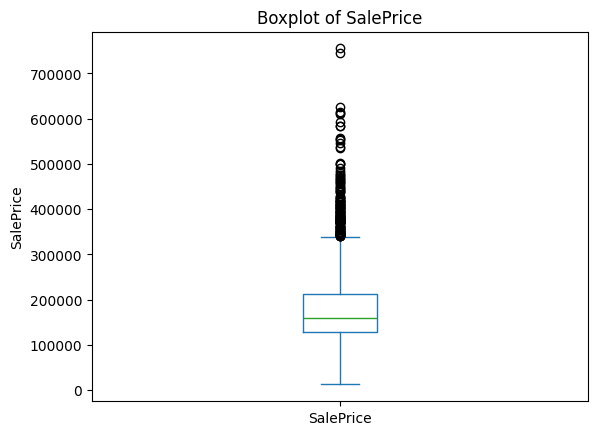

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,rl,141.0,31770,Pave,Unknown,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,rh,80.0,11622,Pave,Unknown,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,rl,81.0,14267,Pave,Unknown,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,rl,93.0,11160,Pave,Unknown,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,rl,74.0,13830,Pave,Unknown,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900.0


In [ ]:
data = get_data()

cleaned_df, dup_count = clean_data(data)

cleaned_df.head()

> One-Hot Encoding




---



In [ ]:
def one_hot_encode(df):
    df = df.copy()
    df = pd.get_dummies(df, columns = ["MS Zoning", "Neighborhood"], drop_first = True)
    return df

> Ordinal Encoding
---



In [ ]:
def ordinal_encode(df):
    df = df.copy()

    quality_order = {
        "Po": 1,
        "Fa": 2,
        "TA": 3,
        "Gd": 4,
        "Ex": 5
        }

    df["Kitchen Qual Ord"] = df["Kitchen Qual"].map(quality_order)

    return df

> Domain Features

---





```
bathroom_ratio is useful because it shows how bathrooms are distributed compared to total rooms.
```

In [ ]:
def create_domain_features(df):
    df = df.copy()

    df["price_per_sqft"] = df["SalePrice"] / df["Gr Liv Area"].replace(0, 1)

    df["bathroom_ratio"] = (df["Full Bath"] + 0.5 * df["Half Bath"]) / df["TotRms AbvGrd"].replace(0, 1)

    return df

> Interaction Feature

---


```
quality_x_area is useful because it combines house size and quality, which together affect the overall value.
```




In [ ]:
def create_interaction_feature(df):
    df = df.copy()
    df["quality_x_area"] = df["Overall Qual"] * df["Gr Liv Area"]

    return df

> Log Transform

---



In [ ]:
def log_transform_feature(df):
    df = df.copy()

    plt.figure(figsize = (6, 4))
    plt.hist(df["Gr Liv Area"], bins = 30)
    plt.title("Gr Liv Area Before Log Transform")
    plt.xlabel("Gr Liv Area")
    plt.ylabel("Count")
    plt.show()

    df["Gr Liv Area Log"] = np.log1p(df["Gr Liv Area"])

    plt.figure(figsize = (6, 4))
    plt.hist(df["Gr Liv Area Log"], bins = 30)
    plt.title("Gr Liv Area After Log Transform")
    plt.xlabel("Gr Liv Area Log")
    plt.ylabel("Count")
    plt.show()

    return df

> Bining Feature

---



In [ ]:
def bin_feature(df):
    df = df.copy()

    df["House Age"] = df["Yr Sold"] - df["Year Built"]

    df["Age Group"] = pd.cut(
        df["House Age"],
        bins=[-1, 20, 50, 200],
        labels=["New", "Recent", "Old"]
    )

    return df

> Train Test Split

---



In [ ]:
def split_data(df):
    train_df, test_df = train_test_split(df, test_size = 0.2, random_state = 42)
    return train_df, test_df

> Scale Numerical Features

---



In [ ]:
def scale_features(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    scaler = StandardScaler()

    scale_cols = ["Gr Liv Area", "Lot Area"]

    train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
    test_df[scale_cols] = scaler.transform(test_df[scale_cols])

    return train_df, test_df

> Remove Redundant Features

---



In [ ]:
def remove_redundant_features(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    corr_matrix = train_df.corr(numeric_only = True).abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool))

    protected_cols = ["Kitchen Qual Ord","price_per_sqft","bathroom_ratio","quality_x_area","Gr Liv Area Log"]

    to_drop = [
        col for col in upper.columns
        if any(upper[col] > 0.95) and col not in protected_cols
        ]

    train_df = train_df.drop(columns = to_drop, errors = "ignore")
    test_df = test_df.drop(columns = to_drop, errors = "ignore")

    return train_df, test_df, to_drop

> Run Phase 2

---



In [ ]:
def run_phase2(df):

    df = one_hot_encode(df)

    df = ordinal_encode(df)

    df = create_domain_features(df)

    df = create_interaction_feature(df)

    df = log_transform_feature(df)

    df = bin_feature(df)

    train_df, test_df = split_data(df)

    train_df, test_df = scale_features(train_df, test_df)

    train_df, test_df, dropped_cols = remove_redundant_features(train_df, test_df)

    features_df = pd.concat([train_df, test_df]).sort_index()

    print("Dropped columns:", dropped_cols)
    print("Final shape:", features_df.shape)

    return features_df

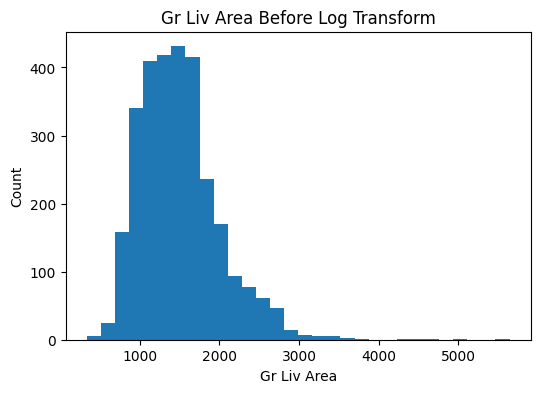

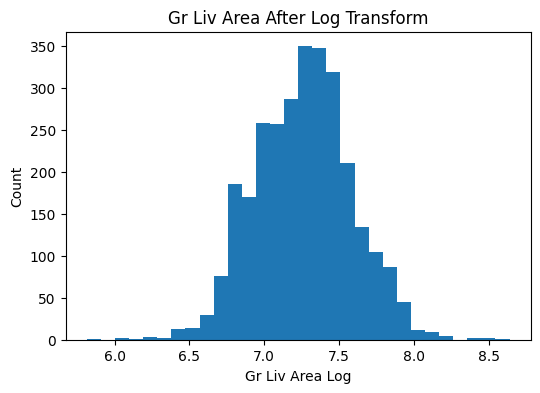

Dropped columns: ['Yr Sold', 'House Age']
Final shape: (2930, 118)


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Neighborhood_stonebr,Neighborhood_swisu,Neighborhood_timber,Neighborhood_veenker,Kitchen Qual Ord,price_per_sqft,bathroom_ratio,quality_x_area,Gr Liv Area Log,Age Group
0,1,526301100,20,141.0,2.688735,Pave,Unknown,IR1,Lvl,AllPub,...,False,False,False,False,3,129.830918,0.142857,9936,7.412764,Recent
1,2,526350040,20,80.0,0.185626,Pave,Unknown,Reg,Lvl,AllPub,...,False,False,False,False,3,117.187500,0.200000,4480,6.799056,Recent
2,3,526351010,20,81.0,0.514231,Pave,Unknown,IR1,Lvl,AllPub,...,False,False,False,False,4,129.420617,0.250000,7974,7.192934,Old
3,4,526353030,20,93.0,0.128229,Pave,Unknown,Reg,Lvl,AllPub,...,False,False,False,False,5,115.639810,0.312500,14770,7.654917,Recent
4,5,527105010,60,74.0,0.459940,Pave,Unknown,IR1,Lvl,AllPub,...,False,False,False,False,3,116.574586,0.416667,8145,7.396335,New


In [ ]:
df_features = run_phase2(cleaned_df)

df_features.head()

> Save Features CSV

---



In [ ]:
df_features.to_csv("data/cleaned/ames_features.csv", index = False)

> Checks

---



In [ ]:
print("Shape:", df_features.shape)

print("\nNew columns:")
print([c for c in df_features.columns if "price" in c or "ratio" in c])

print("\nScaled mean:")
print(df_features[["Gr Liv Area","Lot Area"]].mean())

print('\n')
print(df_features["Age Group"].value_counts())

Shape: (2930, 118)

New columns:
['price_per_sqft', 'bathroom_ratio']

Scaled mean:
Gr Liv Area    0.013539
Lot Area       0.002493
dtype: float64


Age Group
New       1139
Recent     906
Old        884
Name: count, dtype: int64


In [ ]:
print("log:", "Gr Liv Area Log" in df_features.columns)
print("interaction:", "quality_x_area" in df_features.columns)
print("ordinal:", "Kitchen Qual Ord" in df_features.columns)

log: True
interaction: True
ordinal: True
